In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
df=pd.read_csv("aa.csv")

In [3]:
df.head()

,time,tavg,tmin,tmax,prcp
0,01-01-1990,9.4,6.0,15.1,0.0
1,02-01-1990,9.3,5.2,14.2,0.0
2,03-01-1990,9.0,6.5,13.6,0.0
3,04-01-1990,10.7,6.0,17.5,0.0
4,05-01-1990,12.6,7.3,20.8,0.0


In [4]:
df.isnull().sum()

time       0
tavg      94
tmin    1536
tmax     533
prcp    6140
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isnull().sum()

time    0
tavg    0
tmin    0
tmax    0
prcp    0
dtype: int64

In [7]:
df.shape

(4726, 5)

In [26]:
x = df[["tmin", "tmax", "prcp"]]
y = df["tavg"]

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lr=LinearRegression()

In [30]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.51,0.52,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['tmin','tmax','prcp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.284
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [31]:
y_pred = lr.predict(x_test)

In [32]:
y_pred

array([35.21943973, 16.20578261, 20.71992463, 32.61746968, 28.88809879,
       31.78510106, 29.30762947, 25.39495185, 17.05295094, 20.8232266 ,
       31.75027466, 31.69824435, 24.02697761, 16.39260429, 13.19253682,
       19.17485126, 19.01264642, 13.09592759, 32.20128537, 27.73947056,
       27.08464967, 25.26039367, 27.14499298, 17.53302067, 22.32684451,
       26.9284033 , 27.58220519, 31.04450708, 27.32008977, 22.10621353,
       18.448983  , 29.03540842, 26.20744361, 21.18370645, 28.1000375 ,
       16.38613352, 27.76402375, 27.70186907, 28.53743609, 27.44621505,
       35.87815019, 30.18988651, 31.46388979, 14.71306734, 31.26397858,
       18.62271515, 11.74578286, 26.24958185, 32.10132977, 18.15075238,
       24.29854403, 24.737709  , 29.57650325,  9.67259083, 28.42111858,
       28.89053768, 13.68629084, 11.88173465, 31.63918414, 18.87171207,
       31.80800773, 32.23735555, 28.84712004,  8.9635359 , 27.29051934,
       24.33297802, 19.01101023, 34.07673531, 20.39101755, 16.70

In [33]:
x_test

,tmin,tmax,prcp
9261,28.2,42.3,0.0
5085,7.8,25.8,0.0
2611,10.7,31.6,0.0
5281,27.0,38.5,0.0
2301,21.0,37.2,0.0
...,...,...,...
1747,15.0,31.8,0.0
6408,29.0,37.5,0.0
1981,29.3,44.7,0.0
1472,12.2,16.5,16.5


In [34]:
y_test

9261    34.4
5085    15.4
2611    22.1
5281    32.8
2301    29.8
        ... 
1747    24.6
6408    33.6
1981    37.3
1472    14.4
1342    25.7
Name: tavg, Length: 946, dtype: float64

In [35]:
from sklearn.metrics import r2_score

In [36]:
r2 = r2_score(y_test ,y_pred)

In [37]:
r2

0.9775607331603346

In [39]:
m=lr.coef_
m

array([5.07958962e-01, 5.24320867e-01, 3.37166589e-04])

In [40]:
c=lr.intercept_
c

np.float64(-1.2837756575166424)

In [41]:
m*4.0+c

array([ 0.74806019,  0.81350781, -1.28242699])

In [43]:
import pickle

with open("Weather_Temperature_Model.pkl", "wb") as file:
    pickle.dump(lr, file)

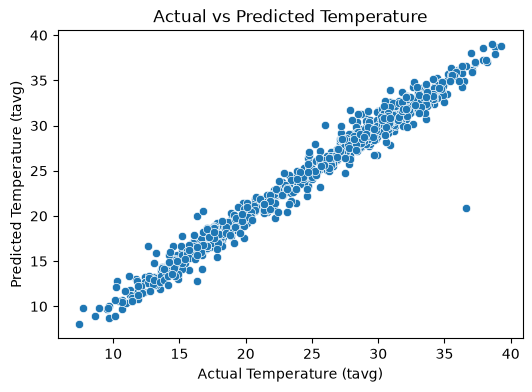

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(x_test)

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Temperature (tavg)")
plt.ylabel("Predicted Temperature (tavg)")
plt.title("Actual vs Predicted Temperature")
plt.show()

In [45]:
from sklearn.metrics import mean_squared_error

In [46]:
print('MSE:',mean_squared_error(y_test,y_pred))

MSE: 1.133278217342633


In [49]:
import pickle

with open("Weather_Temperature_Model.pkl", "wb") as file:
    pickle.dump(lr, file)